![logo](https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/docs/source/_figures/Helmholtz-AI.png?raw=true)

# Hands-On Session: Explainable AI for Random Forest Models

Building on the previously trained Random Forest classifier for **AML vs. non-AML** prediction, this notebook focuses on interpreting and analyzing the model’s decision-making process. Using RNA-seq gene expression data from [Warnat-Herresthal et al. (2020)](https://doi.org/10.1016/j.isci.2019.100780), we apply and compare multiple explainability methods to understand which genes drive the model’s predictions. The objectives of this notebook are to compute and compare model-agnostic and model-specific explanation methods, critically assess their differences, and reflect on the strengths and limitations of each approach in a high-dimensional, multi-study biomedical setting.

--------

## Getting Started

### Setup Colab environment

If you installed the packages and requirements on your own machine, you can skip this section and start from the import section.
Otherwise, you can follow and execute the tutorial on your browser. In order to start working on the notebook, click on the following button. This will open this page in the Colab environment and you will be able to execute the code on your own.

<a href="https://colab.research.google.com/github/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/2026-DKFZ/xai-for-random-forest/7-HandsOn_AML_XAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Now that you opened the notebook in Colab, follow the next step:

1. Run this cell to connect your Google Drive to Colab and install packages
2. Allow this notebook to access your Google Drive files. Click on 'Yes', and select your account.
3. "Google Drive for desktop wants to access your Google Account". Click on 'Allow'.
   
At this point, a folder has been created in your Drive and you can navigate it through the lefthand panel in Colab, you might also have received an email that informs you about the access on your Google Drive.

In [1]:
# Mount drive folder to dbe abale to download repo
from google.colab import drive
drive.mount('/content/drive')

# Switch to correct folder'
%cd /content/drive/MyDrive

In [1]:
# Don't run this cell if you already cloned the repo 
%rm -r XAI-Tutorials
!git clone --branch 2026-DKFZ https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials.git

In [2]:
# Install al required dependencies and package versions
%cd XAI-Tutorials
!pip install -r requirements_xai-for-random-forest.txt
%cd xai-for-random-forest

### Imports

Let's start with importing all required Python packages.

In [3]:
# Load the required packages

import os
import sys
import pickle

import numpy as np
import pandas as pd

import shap
from fgclustering import (
    forest_guided_clustering, 
    forest_guided_feature_importance, 
    plot_forest_guided_feature_importance, 
    plot_forest_guided_decision_paths,
    DistanceRandomForestProximity,
    ClusteringKMedoids,
)
from sklearn.metrics import get_scorer, balanced_accuracy_score
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt

sys.path.append('./')
import utils

Now, we fix the random seeds to ensure reproducible results, as we work with (pseudo) random numbers.

In [4]:
# assert reproducible random number generation
seed = 1
np.random.seed(seed)

## Load Processed Data and Trained Model

In this step, we load the processed RNA-seq dataset and the previously trained Random Forest model. The datasets consist of a total of **1,181 samples** with 508 AML, 74 Leukemia and 599 healthy/other samples drived from two cell types (Peripheral Blood Mononuclear Cells (PBMC) and Bone Marrow (BM)) and 23 studies. The dataset includes **log2-transformed, normalized gene expression values** for over **12,000 genes**. Our goal is to **predict the AML status** and find out the major differences between AML - non-AML samples.

The trained model will serve as the basis for applying and comparing different explainability (XAI) methods.

In [5]:
output_dir = "aml_case_study"

In [6]:
# load previously stored data
with open(os.path.join(output_dir, "data_train_test.pickle"), "rb") as handle:
    data_train, data_test, gene_features = pickle.load(handle)

X_train = data_train[gene_features].reset_index(drop=True)
y_train = data_train["Condition"].reset_index(drop=True)

X_test = data_test[gene_features].reset_index(drop=True)
y_test = data_test["Condition"].reset_index(drop=True)

print(f"Number of training samples {X_train.shape[0]} ({round(X_train.shape[0]/(X_train.shape[0]+X_test.shape[0])*100)}%) with {sum(y_train=='0_Control')} control and {sum(y_train=='1_Cancer')} cancer samples.")
print(f"Number of testing samples {X_test.shape[0]} ({round(X_test.shape[0]/(X_train.shape[0]+X_test.shape[0])*100)}%) with {sum(y_test=='0_Control')} control and {sum(y_test=='1_Cancer')} cancer samples.")

Number of training samples 783 (66%) with 538 control and 245 cancer samples.
Number of testing samples 398 (34%) with 135 control and 263 cancer samples.


In [7]:
# load previously trained model
with open(os.path.join(output_dir, "rf_model.pickle"), "rb") as handle:
    rf_model = pickle.load(handle)

rf_model

RandomForestClassifier(max_depth=10, max_samples=0.8, min_samples_leaf=2,
                       n_estimators=1000, n_jobs=4, oob_score=True,
                       random_state=42)

In [8]:
# check model performance
y_pred_train_val = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

# is the model performing reasonably on the training data?
print(f'Model Performance on training data: {round(balanced_accuracy_score(y_train, y_pred_train_val)*100,2)} % macro accuracy.')

# is the model performing reasonably on the test data?
print(f'Model Performance on test data: {round(balanced_accuracy_score(y_test, y_pred_test)*100,2)} % macro accuracy.')

Model Performance on training data: 100.0 % macro accuracy.
Model Performance on test data: 97.19 % macro accuracy.


## Now, what are our possibilities to interpret a Random Forest model?

After training and evaluating our Random Forest model on the RNA-seq dataset, the next step is to understand *how* the model arrives at its predictions. Tree-based ensemble models are powerful but inherently complex, making their internal decision logic difficult to interpret directly.

In this notebook, we explore and compare different explainability (XAI) approaches that offer complementary perspectives on model behavior. These methods allow us to analyze global feature importance, local prediction mechanisms, and subgroup-specific decision structures. For this analysis, we apply the XAI methods to the **training dataset** in order to investigate what the model has learned during training.

However, it is important to keep in mind that interpretations derived from the training data may reflect training-specific patterns. Therefore, it is always recommended to verify the consistency and stability of explanations on an independent test set to ensure that the identified patterns generalize beyond the training data.

By contrasting their assumptions, strengths, and limitations, we aim to develop a deeper understanding of how interpretability methods behave in high-dimensional, correlated transcriptomic data.

First, we examine the distribution of gene–gene correlations to assess feature dependence in the dataset, as several explainability methods rely on (explicit or implicit) assumptions of feature independence.

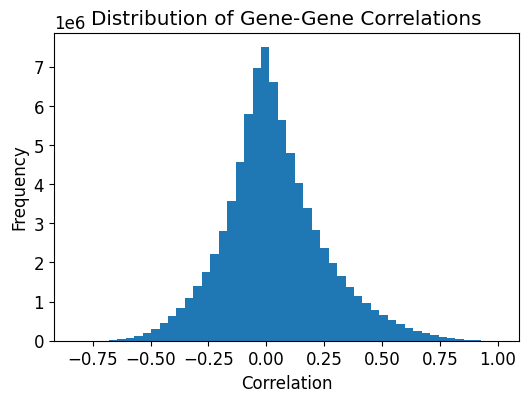

In [9]:
utils.plot_correlation_distribution(data_train)

The distribution of gene–gene correlations shows that many genes exhibit moderate to strong correlations, indicating substantial redundancy in the RNA-seq feature space. This has important implications for explainability methods.

In highly correlated settings, feature importance measures that rely on perturbing individual variables may underestimate the relevance of features, as correlated genes can compensate for each other. Additive attribution methods such as SHAP may distribute importance across correlated predictors, while subgroup-based approaches like Forest-Guided Clustering can capture collective patterns without relying on feature independence assumptions.

Thus, understanding the correlation structure is essential for interpreting and comparing XAI results in high-dimensional transcriptomic data.

In [10]:
# we only want to plot the top features for sake of visualisation
top_n = 30

### Interpretation with Feature Importance Measures

#### Permutation Feature Importance

Recall, the Permutation Feature Importance is defined to be the decrease in a model score when a single feature value is randomly permuted. This procedure breaks the relationship between the feature and the target. Thus the drop in the model score is indicative of how much the model depends on the feature. Lets now apply it to our dataset:

<font color='green'>

#### Task 1: Apply Permutation Feature Importance to identify which genes drive the model’s predictions.

*Note: Computing permutation feature importance can be computationally expensive, particularly in high-dimensional datasets such as RNA-seq data. We therefore recommend running this analysis in a separate notebook to avoid slowing down the remainig tasks. To speed up computations, you can set the n_repeats to 5 or lower.*

#### Random Forest Feature Importance

An alternative to Permutation Feature Importance is the Random Forest specific feature importance method based on the mean decrease in impurity. The mean decrease in impurity is defined as the total decrease in node impurity averaged over all trees of the ensemble. This Feature Importances is directly provided by the fitted attribute `feature_importances_` .

Lets plot the feature importance based on mean decrease in impurity:

In [ ]:
utils.plot_impurity_feature_importance(rf_model.feature_importances_, names=X_train.columns, title="Random Forest Feature Importance", top_n=top_n, figsize=(10,9))

### Interpretation with SHAP

Recall, with SHAP we get contrastive explanations that compare the prediction with the average prediction. The global interpretations are consistent with the local explanations, since the Shapley values are the “atomic unit” of the global interpretations.

<font color='green'>

#### Task 2: Use SHAP to identify the genes with the highest contributions and analyze one AML and one non-AML patient using the SHAP methods introduced earlier.

*Note: To speed up computations, you can initialize the `TreeExplainer` with a smaller background dataset. This may result in slight differences in the expected value (baseline), but in practice these deviations are typically small and do not substantially affect the overall interpretation.*

### Interpretation with Forest-Guided Clustering

Recall, FGC does not assume independence of model features, because it computes the feature importance based on subgroups of instances that follow similar decision rules within the Random Forest model.

<font color='green'>

#### Task 3: Apply Forest-Guided Clustering (FGC) to identify subgroups of samples with similar decision paths in the Random Forest model and analyze how cluster-specific feature importance and metadata distributions provide additional insight beyond global feature attribution methods.

<font color='green'>

#### Question 1: What do you observe when comparing the different XAI methods?